# Multitemporal facet maps: trend and composite

Reads the per-(tile, year) GeoTIFFs written by `scripts/73_map_inference.py` and does two
things with them: a Mann-Kendall trend test per pixel, and an RGB composite of one year.

| | |
|---|---|
| maps from | `scripts/73_map_inference.py` |
| gate | `scripts/74_check_map_consistency.py` |
| spec | `docs/21_map_inference_spec.md` |

## Only three facets

The ensemble emits seven targets from one shared trunk (`head.4.weight` is `(7, 64)`), so
all seven are written to every tile for diagnostics. **Only three of them have any
cross-validated skill**, and every analysis downstream of the maps uses only those.

| facet | block-CV R2 | |
|---|---|---|
| `td_inext_q0` | 0.782 | retained |
| `pd_inext_q0` | 0.594 | retained |
| `lcbd_count_sorensen` | 0.430 | retained |
| `pd_inext_q2` | 0.057 | dropped |
| `pd_inext_q1` | 0.003 | dropped |
| `td_inext_q2` | -0.077 | dropped, worse than the mean |
| `td_inext_q1` | -0.120 | dropped, worse than the mean |

A negative block-CV R2 means the training mean would have been the better predictor. The
four `q1`/`q2` facets are not weak, they are uninformative, and mapping them would produce
a surface that looks exactly as convincing as the other three.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from matplotlib.colors import TwoSlopeNorm
from scipy import stats

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))

TAG = "pilot_cauquenes"
TILE = "t18_600"
MAPS = ROOT / "results/maps" / TAG

#: block-CV reference R2 from the definitive gate, topofix checkpoints.
KEEP = {"td_inext_q0": 0.782, "pd_inext_q0": 0.594, "lcbd_count_sorensen": 0.430}
R2_FLOOR = 0.4
FACETS = [f for f, r in KEEP.items() if r > R2_FLOOR]

LABEL = {"td_inext_q0": "Taxonomic q0 (richness)",
         "pd_inext_q0": "Phylogenetic q0",
         "lcbd_count_sorensen": "LCBD (uniqueness)"}

print(f"retained at block-CV R2 > {R2_FLOOR}: {FACETS}")

retained at block-CV R2 > 0.4: ['td_inext_q0', 'pd_inext_q0', 'lcbd_count_sorensen']


## The autocorrelation problem, and what it forces

Each annual map is built from a **causal 3-year window** `y-2..y`. Consecutive years
therefore share two thirds of their Landsat observations, and the resulting series is
strongly serially autocorrelated by construction.

Mann-Kendall assumes independent observations. Run on all 27 consecutive years its
variance is understated and the p-values are not interpretable — it will report
significance almost everywhere. The defensible series is **every third year**, whose
windows (1998-2000, 2001-2003, ...) tile without overlapping. That is the same spacing
chosen for the full run, which makes the full-run output directly usable here.

Both are computed below, the overlapping one only to show the size of the inflation.

In [2]:
ALL_YEARS = list(range(2000, 2027))
INDEP_YEARS = [2000, 2003, 2006, 2009, 2012, 2015, 2018, 2021, 2024, 2026]


def read_stack(years, facets, tile=TILE, maps=MAPS):
    """`(T, H, W)` per facet plus the per-year native mask and the raster profile."""
    cube, nat, prof = {f: [] for f in facets}, [], None
    for y in years:
        with rasterio.open(maps / f"{tile}_{y}.tif") as src:
            names = list(src.descriptions)
            prof = prof or src.profile
            for f in facets:
                cube[f].append(src.read(names.index(f) + 1).astype(np.float32))
            nat.append(src.read(names.index("native") + 1) > 0.5)
    return {f: np.stack(v) for f, v in cube.items()}, np.stack(nat), prof


def stable_mask(cube, nat):
    """Pixels native AND finite in every time step — the only ones a trend is defined on."""
    m = nat.all(axis=0)
    for v in cube.values():
        m &= np.isfinite(v).all(axis=0)
    return m


cube_i, nat_i, prof = read_stack(INDEP_YEARS, FACETS)
mask_i = stable_mask(cube_i, nat_i)
print(f"{len(INDEP_YEARS)} independent time points; "
      f"{mask_i.sum():,} of {mask_i.size:,} px native and finite in every year "
      f"({100*mask_i.mean():.1f}%)")

10 independent time points; 12,190 of 110,889 px native and finite in every year (11.0%)


Note how few pixels survive: the MapBiomas native mask moves year to year, so requiring
native cover in **all** time steps keeps a stable-forest subset, biased towards cores and
away from the edges where change is most likely. The trend below is conditional on that
subset; it is not a trend over the whole tile.

In [3]:
def mann_kendall(x):
    """Vectorised Mann-Kendall over `x` of shape `(T, N)`, no NaN.

    Returns `S`, Kendall's `tau`, the normal `z`, the two-sided `p` and the Theil-Sen slope
    per unit time step. Ties are not corrected for: these are continuous predictions and
    exact ties do not occur.
    """
    T, N = x.shape
    S = np.zeros(N)
    for k in range(1, T):
        S += np.sign(x[k:] - x[:-k]).sum(axis=0)
    var = T * (T - 1) * (2 * T + 5) / 18.0
    z = np.where(S > 0, (S - 1) / np.sqrt(var),
                 np.where(S < 0, (S + 1) / np.sqrt(var), 0.0))
    p = 2 * (1 - stats.norm.cdf(np.abs(z)))
    tau = S / (0.5 * T * (T - 1))
    slopes = np.stack([(x[j] - x[i]) / (j - i)
                       for i in range(T - 1) for j in range(i + 1, T)])
    return S, tau, z, p, np.median(slopes, axis=0)


def bh_fdr(p, q=0.05):
    """Benjamini-Hochberg. With ~10^4 pixels tested, an uncorrected p < 0.05 is noise."""
    n = len(p)
    order = np.argsort(p)
    below = p[order] <= q * np.arange(1, n + 1) / n
    k = int(np.flatnonzero(below).max()) + 1 if below.any() else 0
    out = np.zeros(n, bool)
    out[order[:k]] = True
    return out


def run_mk(years, label):
    cube, nat, _ = read_stack(years, FACETS)
    mask = stable_mask(cube, nat)
    idx = np.flatnonzero(mask.ravel())
    step = years[1] - years[0]
    rows, fields = [], {}
    for f in FACETS:
        x = cube[f].reshape(len(years), -1)[:, idx]
        S, tau, z, p, slope = mann_kendall(x)
        sig = bh_fdr(p)
        rows.append(dict(facet=f, tau=np.median(tau), slope_yr=np.median(slope) / step,
                         p05=100 * (p < 0.05).mean(), fdr=100 * sig.mean(),
                         up=100 * (sig & (S > 0)).mean(), down=100 * (sig & (S < 0)).mean()))
        fields[f] = dict(tau=tau, slope=slope / step, sig=sig, S=S)
    print(f"\n{label}: T={len(years)}, {len(idx):,} px")
    print(f"{'facet':22s} {'tau_med':>8s} {'slope/yr':>12s} {'p<.05':>7s} "
          f"{'FDR5%':>7s} {'up':>6s} {'down':>6s}")
    for r in rows:
        print(f"{r['facet']:22s} {r['tau']:+8.3f} {r['slope_yr']:+12.3e} "
              f"{r['p05']:6.1f}% {r['fdr']:6.1f}% {r['up']:5.1f}% {r['down']:5.1f}%")
    return fields, mask, idx, rows


fields_i, mask_i, idx_i, rows_i = run_mk(INDEP_YEARS, "INDEPENDENT (every 3rd year)")
_, _, _, rows_a = run_mk(ALL_YEARS, "OVERLAPPING (all 27 years) -- inflated, do not report")


INDEPENDENT (every 3rd year): T=10, 12,190 px
facet                   tau_med     slope/yr   p<.05   FDR5%     up   down
td_inext_q0              -0.467   -2.316e-02   64.4%   49.5%  10.2%  39.3%
pd_inext_q0              -0.600   -3.273e-02   65.2%   56.1%   0.1%  56.0%
lcbd_count_sorensen      -0.644   -2.382e-07   66.6%   57.2%   0.1%  57.1%



OVERLAPPING (all 27 years) -- inflated, do not report: T=27, 11,060 px
facet                   tau_med     slope/yr   p<.05   FDR5%     up   down
td_inext_q0              -0.350   -1.831e-02   81.8%   80.6%  26.2%  54.4%
pd_inext_q0              -0.464   -2.415e-02   72.1%   70.5%   3.4%  67.1%
lcbd_count_sorensen      -0.453   -1.716e-07   72.8%   70.8%   4.2%  66.6%


The inflation is the point of the second table: on overlapping windows the fraction of
pixels called significant after FDR rises substantially for every facet, without the
underlying data having changed. Report the first table.

All three facets trend **downward** over the stable-native subset of this tile. That is a
result about one 10 km tile in Cauquenes over 2000-2026, not about Chile.

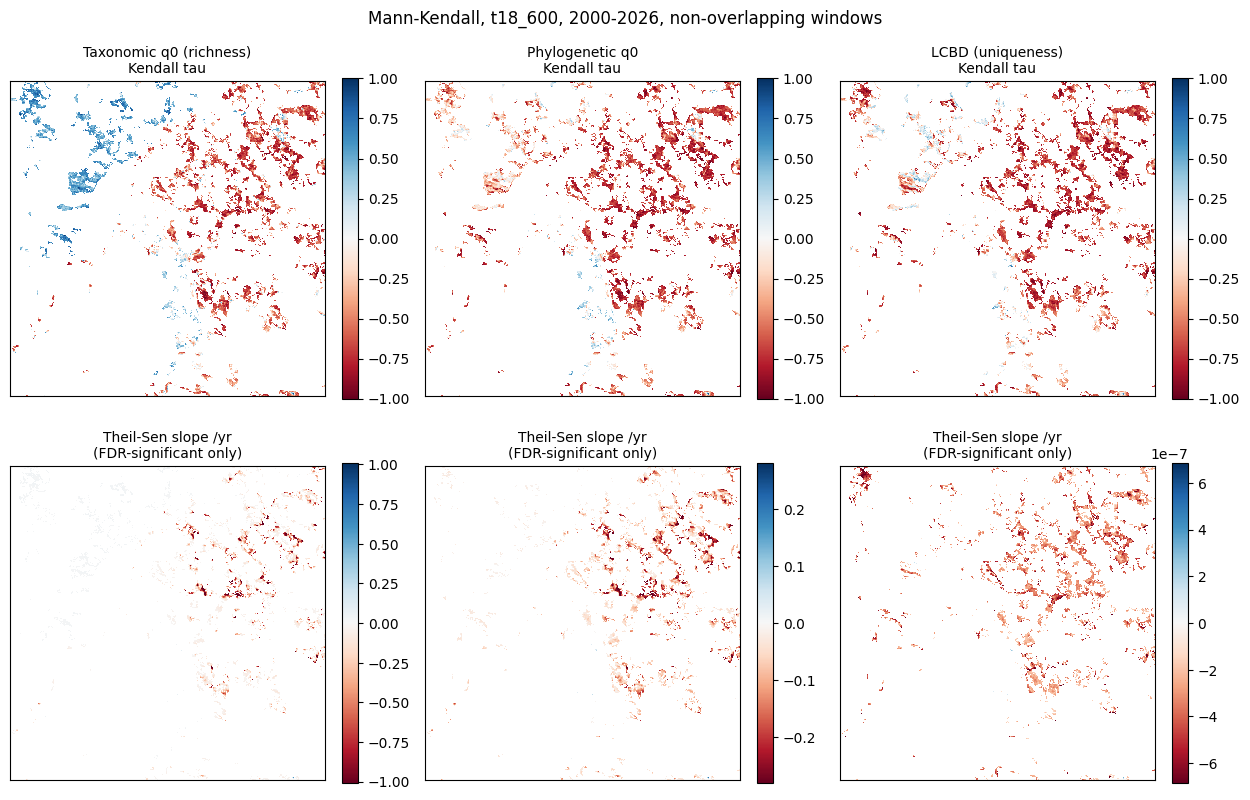

In [4]:
fig, axes = plt.subplots(2, len(FACETS), figsize=(4.2 * len(FACETS), 8.2))
for j, f in enumerate(FACETS):
    tau = np.full(mask_i.shape, np.nan).ravel()
    tau[idx_i] = fields_i[f]["tau"]
    tau = tau.reshape(mask_i.shape)

    sl = np.full(mask_i.shape, np.nan).ravel()
    sl[idx_i] = np.where(fields_i[f]["sig"], fields_i[f]["slope"], np.nan)
    sl = sl.reshape(mask_i.shape)

    ax = axes[0, j]
    im = ax.imshow(tau, cmap="RdBu", norm=TwoSlopeNorm(0, -1, 1), interpolation="nearest")
    ax.set_title(f"{LABEL[f]}\nKendall tau", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)

    ax = axes[1, j]
    v = np.nanpercentile(np.abs(sl), 98) if np.isfinite(sl).any() else 1.0
    im = ax.imshow(sl, cmap="RdBu", norm=TwoSlopeNorm(0, -v, v), interpolation="nearest")
    ax.set_title("Theil-Sen slope /yr\n(FDR-significant only)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
fig.suptitle(f"Mann-Kendall, {TILE}, {INDEP_YEARS[0]}-{INDEP_YEARS[-1]}, "
             f"non-overlapping windows", fontsize=12)
fig.tight_layout()
plt.show()

## RGB composite

The three facets live on completely different scales — LCBD is around 4e-4, taxonomic q0
reaches 44 — so they are **z-normalised independently** across the tile before being put
in a colour channel. Without that the composite would show one facet and two black
channels.

The z-scores are clipped at +/-2.5 sigma before scaling to `[0, 1]`. The clip is cosmetic
and it is asymmetric in effect: the maps already under-disperse the upper tail (see
`docs/21` section 6), so the bright end of each channel is compressed twice. Read the
composite as *where the three facets disagree*, not as a magnitude.

z-normalisation over 52,959 native px of 2015:
  td_inext_q0            mean      7.32118   sd      2.37881
  pd_inext_q0            mean      5.56249   sd      1.09895
  lcbd_count_sorensen    mean  0.000413455   sd  1.09384e-05


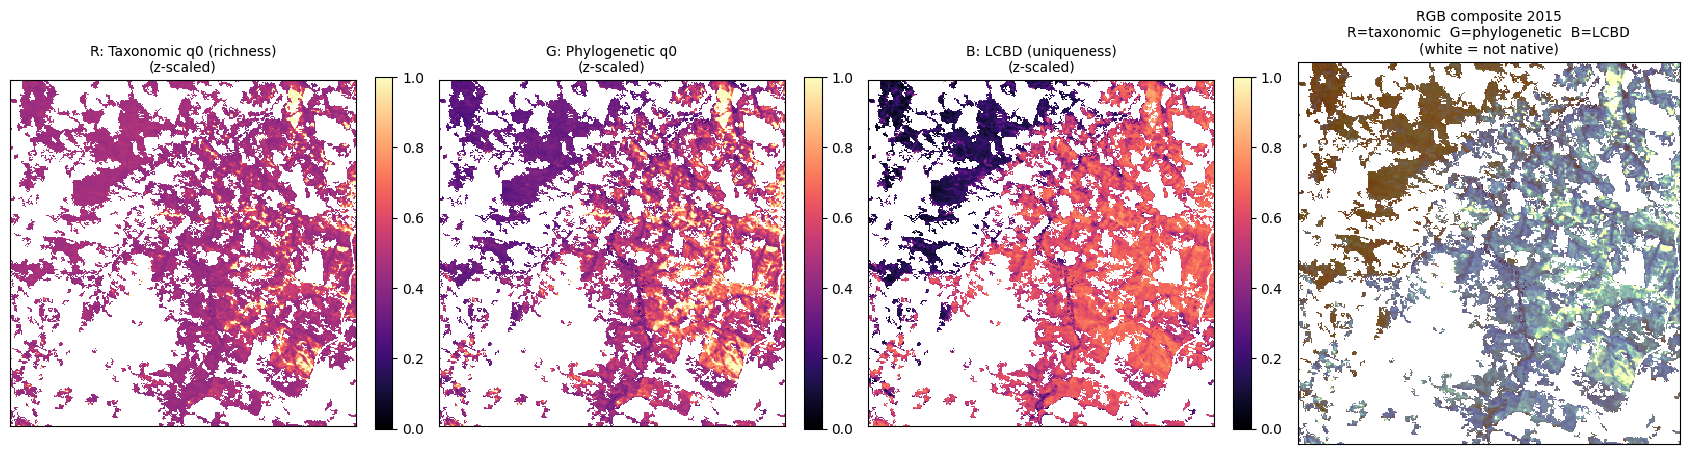

In [5]:
YEAR = 2015
CHANNELS = ["td_inext_q0", "pd_inext_q0", "lcbd_count_sorensen"]   # -> R, G, B


def z_composite(year, channels=CHANNELS, clip=2.5, tile=TILE, maps=MAPS):
    """`(H, W, 3)` in [0,1] plus the per-channel (mean, sd) used, and the native mask."""
    with rasterio.open(maps / f"{tile}_{year}.tif") as src:
        names = list(src.descriptions)
        bands = {c: src.read(names.index(c) + 1).astype(float) for c in channels}
        native = src.read(names.index("native") + 1) > 0.5
    rgb = np.zeros(native.shape + (3,), float)
    used = {}
    for k, c in enumerate(channels):
        a = np.where(native, bands[c], np.nan)
        mu, sd = np.nanmean(a), np.nanstd(a)
        z = np.clip((a - mu) / sd, -clip, clip)
        rgb[..., k] = (z + clip) / (2 * clip)
        used[c] = (float(mu), float(sd))
    rgb[~native] = np.nan
    return rgb, used, native


rgb, used, native = z_composite(YEAR)
print(f"z-normalisation over {native.sum():,} native px of {YEAR}:")
for c, (mu, sd) in used.items():
    print(f"  {c:22s} mean {mu:12.6g}   sd {sd:12.6g}")

fig, axes = plt.subplots(1, 4, figsize=(17, 4.6))
for k, c in enumerate(CHANNELS):
    ax = axes[k]
    im = ax.imshow(np.where(native, rgb[..., k], np.nan), cmap="magma", vmin=0, vmax=1,
                   interpolation="nearest")
    ax.set_title(f"{'RGB'[k]}: {LABEL[c]}\n(z-scaled)", fontsize=10)
    ax.set_xticks([]); ax.set_yticks([])
    fig.colorbar(im, ax=ax, fraction=0.046)
ax = axes[3]
# Non-native pixels are painted white, not black: black is a legitimate value here (low in
# all three facets), so filling nodata with zeros would make "masked out" and "low
# everywhere" the same colour and there would be no way to tell them apart.
ax.imshow(np.where(np.isnan(rgb), 1.0, rgb), interpolation="nearest")
ax.set_title(f"RGB composite {YEAR}\nR=taxonomic  G=phylogenetic  B=LCBD"
             "\n(white = not native)", fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
fig.tight_layout()
plt.show()

Reading the composite: grey/white means the three facets agree (all high or all low);
saturated colour means they disagree. A red patch is taxonomically rich but
phylogenetically ordinary and not compositionally unusual; blue is a pixel whose
contribution to beta diversity is high without high richness.

## What this notebook does not license

* The trend is over the pixels native in **every** time step, a stable-forest subset.
* One 10 km tile. Nothing here is a statement about Chile.
* The predictions are conditional means and under-disperse the upper tail; the GeoTIFF
  tags carry that caveat verbatim. Use the surfaces as relative, not absolute.
* The four `q1`/`q2` facets in the rasters have no cross-validated skill and are excluded
  here by construction. They are written for diagnostics only.